In [57]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns

In [5]:
x=[1,2,3,4,10]
y=[5,4,3,2,1]

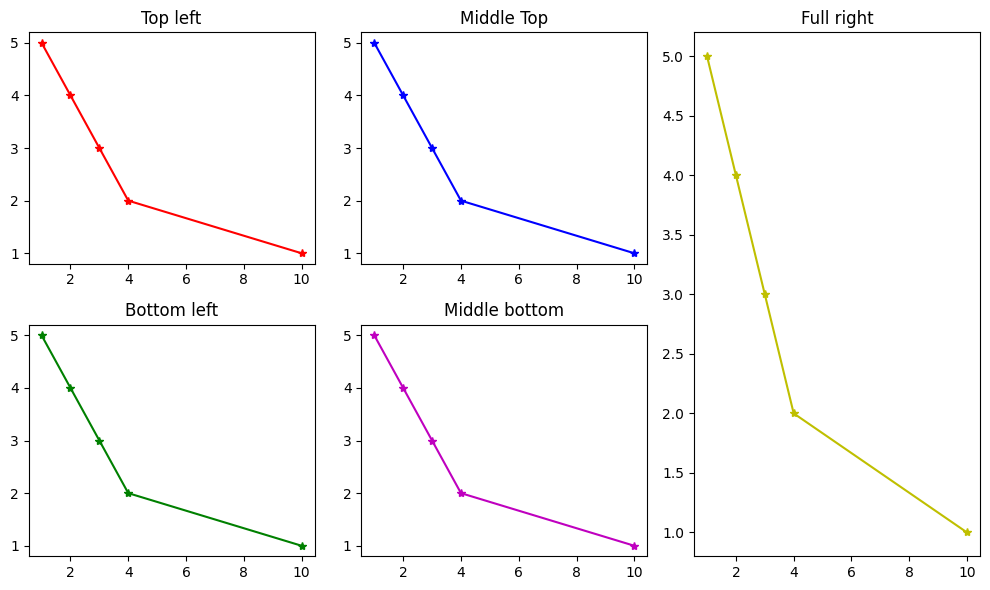

In [27]:
fig = plt.figure(figsize=(10,6))

gs = gridspec.GridSpec(2,3)

ax1 = fig.add_subplot(gs[0,0])
ax1.plot(x,y,'r-*')
ax1.set_title('Top left')

ax2 = fig.add_subplot(gs[1,0])
ax2.plot(x,y,'g-*')
ax2.set_title('Bottom left')

ax3 = fig.add_subplot(gs[0,1])
ax3.plot(x,y,'b-*')
ax3.set_title('Middle Top')

ax4 = fig.add_subplot(gs[1,1])
ax4.plot(x,y,'m-*')
ax4.set_title('Middle bottom')

ax4 = fig.add_subplot(gs[:,2])
ax4.plot(x,y,'y-*')
ax4.set_title('Full right')

plt.tight_layout()
plt.show()

In [ ]:
#####

In [28]:
df = pd.read_csv('Time Series data.csv')

In [30]:
df.head()

,Avg_Temperature,Ice_Cream_Sales,Power_Cuts
0,25.661274,591.163282,5.0
1,26.560024,657.393558,3.0
2,28.596623,779.978584,4.0
3,28.104512,726.827852,5.0
4,29.889647,775.217459,5.0


In [31]:
df.shape

(120, 3)

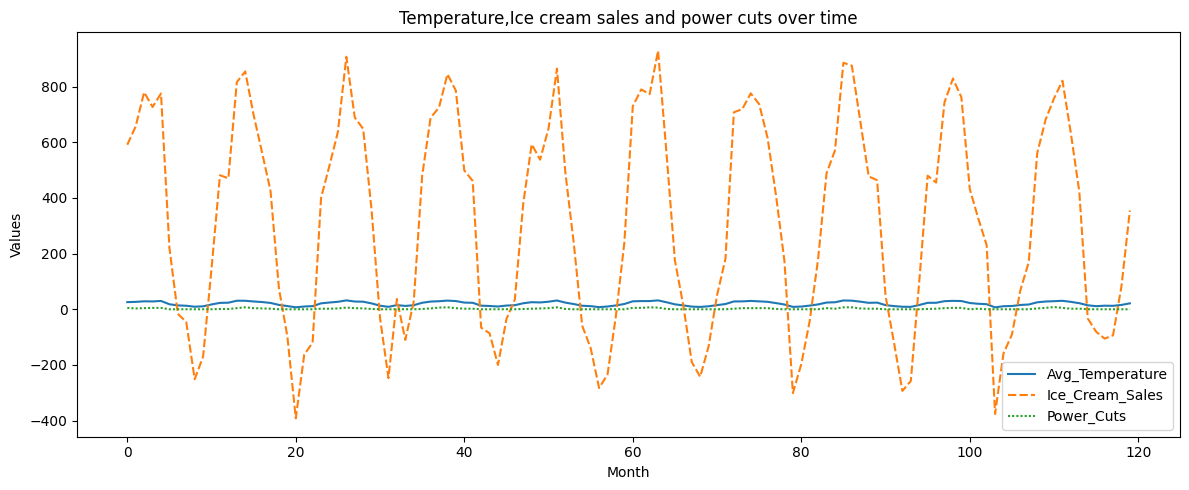

In [38]:
plt.figure(figsize=(12,5))

sns.lineplot(data=df[['Avg_Temperature','Ice_Cream_Sales','Power_Cuts']])
plt.title('Temperature,Ice cream sales and power cuts over time')
plt.xlabel('Month')
plt.ylabel('Values')

plt.tight_layout()
plt.show()

In [39]:
df['Temperature_MA_6'] = df['Avg_Temperature'].rolling(window=6).mean()
df['IceCream_Sales_MA_6'] = df['Ice_Cream_Sales'].rolling(window=6).mean()

In [41]:
df.head(10)

,Avg_Temperature,Ice_Cream_Sales,Power_Cuts,Temperature_MA_6,IceCream_Sales_MA_6
0,25.661274,591.163282,5.0,NaN,NaN
1,26.560024,657.393558,3.0,NaN,NaN
2,28.596623,779.978584,4.0,NaN,NaN
3,28.104512,726.827852,5.0,NaN,NaN
4,29.889647,775.217459,5.0,NaN,NaN
5,18.074189,220.867731,0.0,26.147711,625.241411
6,13.913798,-16.165218,0.0,24.189799,524.019994
7,12.661206,-45.941386,0.0,21.873329,406.797504
8,9.110366,-251.292061,0.0,18.625619,234.919063
9,10.641652,-170.066611,0.0,15.715143,85.436652


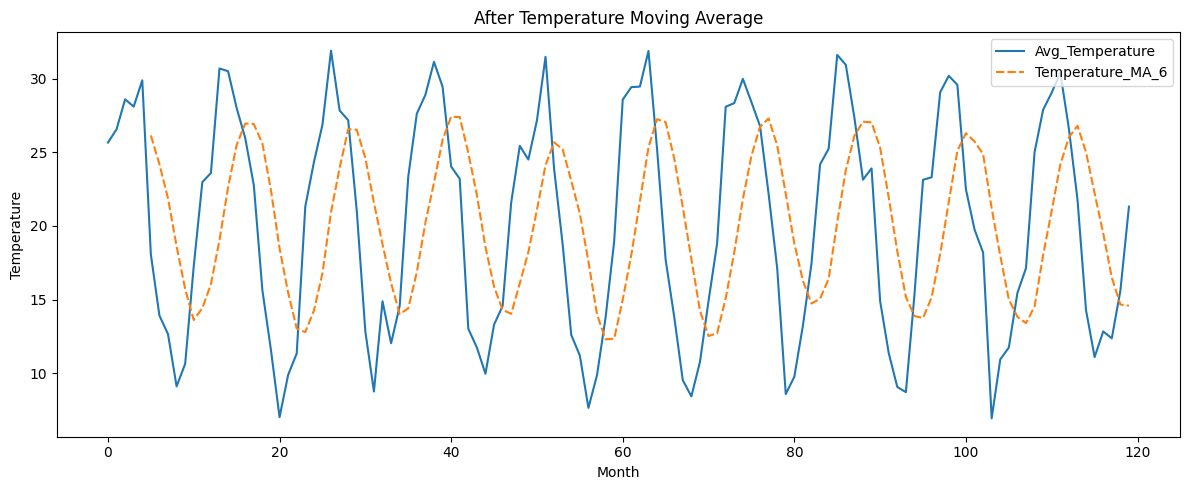

In [43]:
plt.figure(figsize=(12,5))
#lineplot
sns.lineplot(data=df[['Avg_Temperature','Temperature_MA_6']])
plt.title('After Temperature Moving Average')
plt.xlabel('Month')
plt.ylabel('Temperature')

plt.tight_layout()
plt.show()

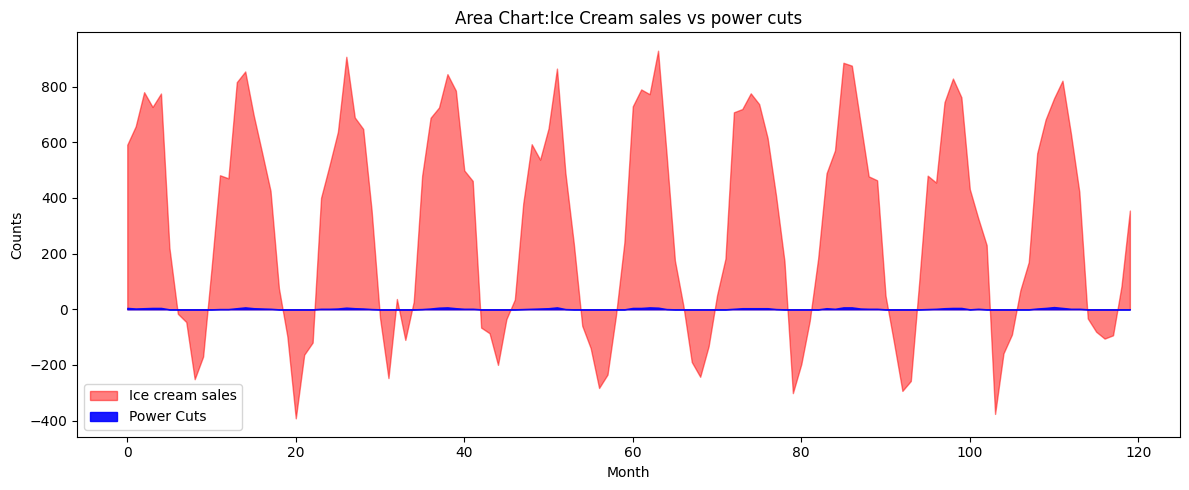

In [52]:
plt.figure(figsize=(12,5))
#areaplot
plt.fill_between(df.index,df['Ice_Cream_Sales'],color='red',alpha=0.5,label='Ice cream sales')
plt.fill_between(df.index,df['Power_Cuts'],color='blue',alpha=0.9,label='Power Cuts')
plt.title('Area Chart:Ice Cream sales vs power cuts')
plt.xlabel('Month')
plt.ylabel('Counts')

plt.legend()
plt.tight_layout()
plt.show()

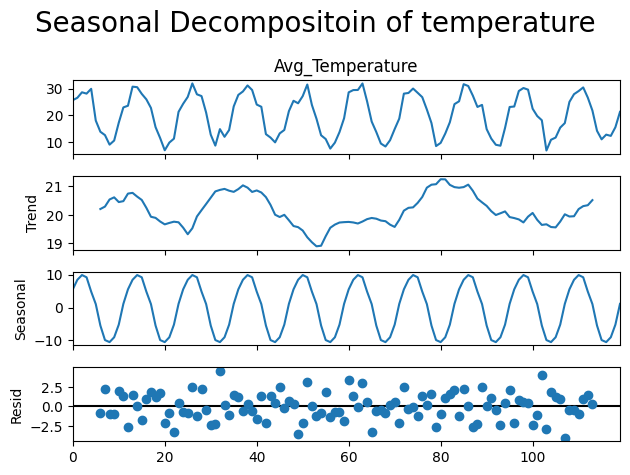

In [68]:
result = seasonal_decompose(df['Avg_Temperature'],model='aditive',period=12)
result.plot()
plt.suptitle('Seasonal Decompositoin of temperature',fontsize=20)

plt.tight_layout()
plt.show()